# 2D Flow Matching model

This notebook is adapted from an example of [`facebookresearch/flow_matching`](https://github.com/facebookresearch/flow_matching/).

- Dataset: 2D checkerboard
- Velocity model: MLP

## Imports and init device

In [1]:
import matplotlib.pyplot as plt
from matplotlib import cm

import torch
from torch import nn, Tensor

from dlk.opt.train_diffusion import train_epochs
from dlk.nets.diffusion import ODESolver

# avoide meshgrid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch")

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

print(device)

cpu


In [3]:
torch.manual_seed(42)

## Dataset

In [4]:
def inf_train_gen(batch_size: int = 200, device: str = "cpu"):
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size, ), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)

    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    
    return data.float()

In [5]:
class GeneratorDataset:
    """Wraps a batch-generating callable as a DataLoaderType-compatible dataset.

    Calls `generate_fn` once per iteration to produce a batch. Satisfies
    `DataLoaderType` directly without requiring a `DataLoader` wrapper.

    Args:
        generate_fn: Callable with signature `(batch_size, device) -> Tensor`.
        n_batches: Number of batches to yield per epoch.
        batch_size: Batch size passed to `generate_fn`.
        device: Device passed to `generate_fn`.
    """

    def __init__(self, generate_fn, n_batches, batch_size, device):
        self.generate_fn = generate_fn
        self.n_batches = n_batches
        self.batch_size = batch_size
        self.device = device

    def __iter__(self):
        for _ in range(self.n_batches):
            yield self.generate_fn(batch_size=self.batch_size, device=self.device)

    def __len__(self) -> int:
        return self.n_batches

## Model

In [6]:
# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim

        self.layers = nn.Sequential(
            nn.Linear(input_dim+time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
        )
    

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t], dim=1)
        output = self.layers(h)
        
        return output.reshape(*sz)

## Train Velocity Flow Matching model

In [7]:
# training arguments
lr = 0.001
batch_size = 4096
epochs = 10000
hidden_dim = 32

# create data generator
data_generator = GeneratorDataset(inf_train_gen, n_batches=1, batch_size=batch_size, device=device)

# velocity field model init
vf = MLP(input_dim=2, time_dim=1, hidden_dim=hidden_dim).to(device) 

# init optimizer
optim = torch.optim.Adam(vf.parameters(), lr=lr) 

# train
train_dlog = train_epochs(
    n_epochs=epochs,
    net=vf,
    dataloader=data_generator,
    optimizer=optim,
    loss_fn=nn.MSELoss(),
    lr_scheduler=None,
    device=device,
)

epochs: 100%|██████████| 10000/10000 [00:22<00:00, 447.15it/s]


#### Sample from trained model

In [8]:
forward_solver = ODESolver(velocity_model=vf)

In [9]:
batch_size = 50000  # batch size
step_size = 0.05  # step size for ode solver

time_grid = torch.linspace(0, 1, 10, device=device)
x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)

sol = forward_solver.sample(
    x_init=x_init,
    step_size=step_size,
    method="midpoint",
    time_grid=time_grid,
    return_intermediates=True,
)

### Visualize the path

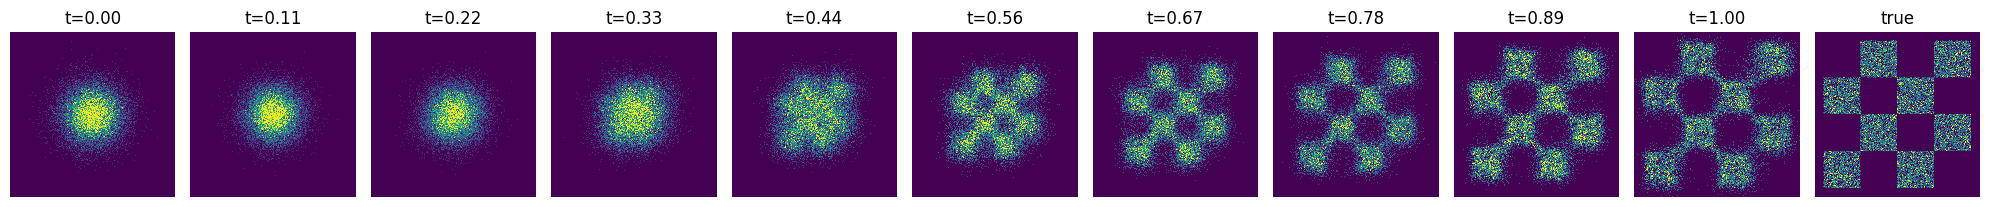

In [10]:
sol_np = sol.cpu().numpy()
time_grid_np = time_grid.cpu().numpy()

fig, axs = plt.subplots(1, 10+1, figsize=(20,20))
norm = cm.colors.Normalize(vmax=50, vmin=0)

for i in range(10):
    H = axs[i].hist2d(sol_np[i,:,0], sol_np[i,:,1], 300, range=((-5,5), (-5,5)))
    
    cmin = 0.0
    cmax = torch.quantile(torch.from_numpy(H[0]), 0.99).item()
    
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
    
    axs[i].hist2d(sol_np[i,:,0], sol_np[i,:,1], 300, range=((-5,5), (-5,5)), norm=norm)
    axs[i].set_aspect("equal")
    axs[i].axis("off")
    axs[i].set_title(f"t={time_grid_np[i]:.2f}")

x_true = inf_train_gen(batch_size).numpy()   
axs[-1].hist2d(x_true[:,0], x_true[:,1], 300, range=((-5,5), (-5,5)), norm=norm)
axs[-1].set_aspect("equal")
axs[-1].axis("off")
axs[-1].set_title("true")
    
plt.tight_layout()
plt.show()

## Compute and Visualize Model Log-likelihood

In [11]:
from torch.distributions import Independent, Normal

In [12]:
# sample with likelihood
grid_size = 200

T = torch.tensor([1., 0.])  # sample times
T = T.to(device=device)

x_1 = torch.meshgrid(torch.linspace(-5, 5, grid_size), torch.linspace(-5, 5, grid_size))
x_1 = torch.stack([x_1[0].flatten(), x_1[1].flatten()], dim=1).to(device)

In [13]:
# source distribution is an isotropic gaussian
gaussian_log_density = Independent(Normal(torch.zeros(2, device=device), torch.ones(2, device=device)), 1).log_prob

# compute log likelihood with unbiased hutchinson estimator, average over num_acc
num_acc = 10
log_p_acc = 0

for i in range(num_acc):
    _, log_p = forward_solver.compute_likelihood(x_1=x_1, method="midpoint", step_size=step_size, exact_divergence=False, log_p0=gaussian_log_density)
    log_p_acc += log_p

log_p_acc /= num_acc

# compute with exact divergence
_, exact_log_p = forward_solver.compute_likelihood(x_1=x_1, method="midpoint", step_size=step_size, exact_divergence=True, log_p0=gaussian_log_density)

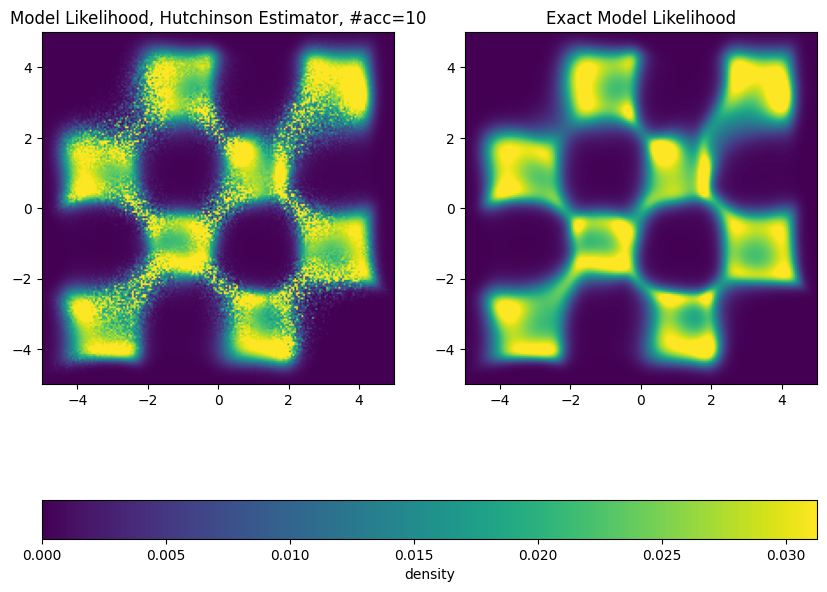

In [14]:
likelihood = torch.exp(log_p_acc).cpu().reshape(grid_size, grid_size).detach().numpy()
exact_likelihood = torch.exp(exact_log_p).cpu().reshape(grid_size, grid_size).detach().numpy()

fig, axs = plt.subplots(1, 2,figsize=(10,10))

cmin = 0.0
cmax = 1/32 # 1/32 is the gt likelihood value

norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

axs[0].imshow(likelihood, extent=(-5, 5, -5, 5), origin="lower", cmap="viridis", norm=norm)
axs[0].set_title(f"Model Likelihood, Hutchinson Estimator, #acc={num_acc}")

axs[1].imshow(exact_likelihood, extent=(-5, 5, -5, 5), origin="lower", cmap="viridis", norm=norm)
axs[1].set_title('Exact Model Likelihood')

fig.colorbar(cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axs, orientation="horizontal", label="density")
plt.show()